**Prática de Realce e detecção de borda**

Exercícios retirados de:
http://homepages.inf.ed.ac.uk/rbf/HIPR2/featops.htm



In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Aplique os filtros  Sobel e Roberts nas imagens abaixo. Mostre, para o caso do Sobel, uma imagem representando a derivada em x e outra imagem representando a derivada em y

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

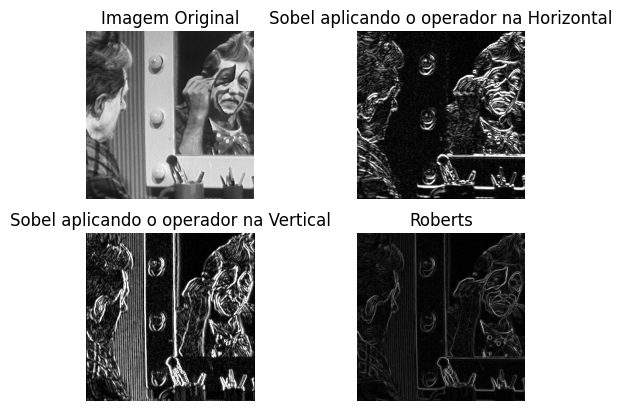

In [2]:
img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)

# Máscara utilizando o gradiente-cruzado de Roberts
gradienteH1 = np.array([[1,0],[0,-1]])
gradienteH2 = np.array([[0,1],[-1,0]])

# Máscara utilizando o operador de sobel (horizontal e vertical)
gradienteSobelH = np.array([[-1,-2,-1], [0,0,0], [1,2,1]])
gradienteSobelV = np.array([[-1, 0, 1], [-2,0,2], [-1,0,1]])

# Filtro utilizando roberts
filtroH1 = cv2.filter2D(img1, cv2.CV_64F, gradienteH1)
filtroH2 = cv2.filter2D(img1, cv2.CV_64F, gradienteH2)

# Filtro utilizando sobel
filtroHorizontal = cv2.filter2D(img1, cv2.CV_64F, gradienteSobelH)
filtroVertical = cv2.filter2D(img1, cv2.CV_64F, gradienteSobelV)

# Imagens tem valores negativos, por isso a conversão, senão não dá pra ver
raiz = np.sqrt(filtroH1**2 + filtroH2**2)
imgRoberts = cv2.convertScaleAbs(raiz)

imgHorizontal = cv2.convertScaleAbs(filtroHorizontal)
imgVertical = cv2.convertScaleAbs(filtroVertical)

# Imagem original
plt.subplot(2,2,1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255);
plt.title("Imagem Original")
plt.axis('off')

# Sobel
plt.subplot(2,2,2)
plt.imshow(imgHorizontal, cmap = "gray", vmin=0, vmax=255);
plt.title("Sobel aplicando o operador na Horizontal")
plt.axis('off')

# Sobel
plt.subplot(2,2,3)
plt.imshow(imgVertical, cmap = "gray", vmin=0, vmax=255);
plt.title("Sobel aplicando o operador na Vertical")
plt.axis('off')

# Roberts
plt.subplot(2,2,4)
plt.imshow(imgRoberts, cmap = "gray", vmin=0, vmax=255);
plt.title("Roberts")
plt.axis('off')

2) Utilizando a imagem do exercício anterior, realce as bordas utilizando (a) Filtro Laplaciano. (b) Unsharp masking. (c) Highboost filtering (escolher um k). (d) K <1 para atenuar

In [ ]:
img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)

# ── (a) Filtro Laplaciano ────────────────────────────────────────────────────
# Kernel Laplaciano (segunda derivada) – realça bordas em todas as direções
laplaciano_kernel = np.array([[0,  1, 0],
                               [1, -4, 1],
                               [0,  1, 0]])
filtro_lap = cv2.filter2D(img1, cv2.CV_64F, laplaciano_kernel)
# Realce: subtrai o Laplaciano (sinal negativo no centro → subtração amplia bordas)
realce_lap = np.clip(img1.astype(np.float64) - filtro_lap, 0, 255).astype(np.uint8)

# ── (b) Unsharp Masking ─────────────────────────────────────────────────────
# mask = img - blur  →  resultado = img + c * mask  (c = 1)
blur = cv2.GaussianBlur(img1, (5, 5), 1.0)
mask = img1.astype(np.float64) - blur.astype(np.float64)
c = 1.0
unsharp = np.clip(img1.astype(np.float64) + c * mask, 0, 255).astype(np.uint8)

# ── (c) Highboost Filtering – k > 1 (realce agressivo) ──────────────────────
# resultado = k * img - blur   (equivalente a img + (k-1)*(img - blur))
k = 2.0
highboost = np.clip(k * img1.astype(np.float64) - blur.astype(np.float64), 0, 255).astype(np.uint8)

# ── (d) Highboost – k < 1 (atenuação de bordas) ─────────────────────────────
k_aten = 0.5
highboost_aten = np.clip(k_aten * img1.astype(np.float64) - blur.astype(np.float64), 0, 255).astype(np.uint8)

# ── Exibição ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
titles = ["Original",
          "(a) Laplaciano",
          "(b) Unsharp Masking\n(c=1)",
          "(c) Highboost\n(k=2)",
          "(d) Highboost\n(k=0.5 – atenuação)"]
images = [img1, realce_lap, unsharp, highboost, highboost_aten]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle("Questão 2 – Realce de Bordas", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

3) Aplique o operador Sobel imagem original abaixo e obtenha as outras imagens conforme descrição. We can see that the intensity of many pixels on the surface is as high as along the actual edges. One reason is that the output of many edge pixels is greater than the maximum pixel value and therefore they are `cut off' at 255. To avoid this overflow we scale the range image by a factor 0.25 prior to the edge detection and then normalize the output, as can be seen in (c)

In [ ]:
img2 = cv2.imread("ren1.png", cv2.IMREAD_GRAYSCALE)

# Kernels Sobel
gradienteSobelH = np.array([[-1, -2, -1],
                              [ 0,  0,  0],
                              [ 1,  2,  1]])
gradienteSobelV = np.array([[-1, 0, 1],
                              [-2, 0, 2],
                              [-1, 0, 1]])

# ── (a) Imagem original ──────────────────────────────────────────────────────
# (exibida como referência)

# ── (b) Sobel direto – sem escala (overflow em 255) ─────────────────────────
fH = cv2.filter2D(img2, cv2.CV_64F, gradienteSobelH)
fV = cv2.filter2D(img2, cv2.CV_64F, gradienteSobelV)
sobel_orig = cv2.convertScaleAbs(np.sqrt(fH**2 + fV**2))
# Pixels de borda estouram 255 → perda de detalhes (clipping)

# ── (c) Img × 0.25 → Sobel (sem overflow) ───────────────────────────────────
img2_scaled = img2.astype(np.float64) * 0.25
fH2 = cv2.filter2D(img2_scaled, cv2.CV_64F, gradienteSobelH)
fV2 = cv2.filter2D(img2_scaled, cv2.CV_64F, gradienteSobelV)
sobel_scaled_raw = np.sqrt(fH2**2 + fV2**2)
sobel_scaled = cv2.convertScaleAbs(sobel_scaled_raw)
# Range menor → sem clipping, mas saída escura

# ── (d) Img × 0.25 → Sobel → Normalização ───────────────────────────────────
# Normaliza para [0, 255]: aproveita toda a faixa dinâmica sem overflow
sobel_norm = cv2.normalize(sobel_scaled_raw, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# ── Exibição ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ["(a) Original",
          "(b) Sobel s/ escala\n(overflow → clipping)",
          "(c) Img×0.25 → Sobel\n(sem overflow, escuro)",
          "(d) Img×0.25 → Sobel\n+ Normalização"]
images = [img2, sobel_orig, sobel_scaled, sobel_norm]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle("Questão 3 – Sobel com escala para evitar overflow", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

4) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

(np.float64(-0.5), np.float64(299.5), np.float64(439.5), np.float64(-0.5))

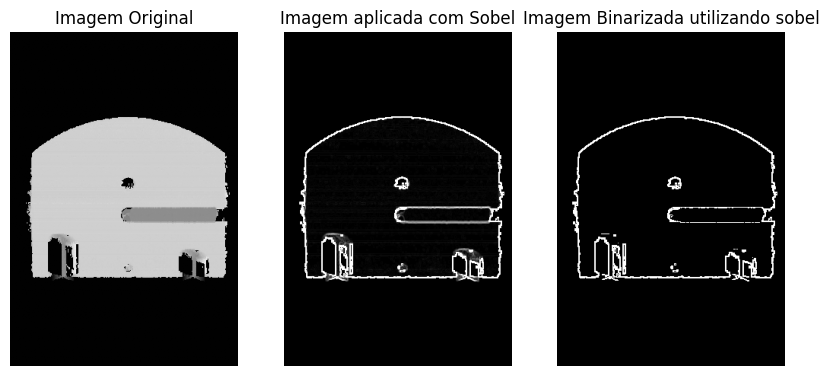

In [3]:
img1 = cv2.imread("ufo2.png", cv2.IMREAD_GRAYSCALE)

# Máscara utilizando o operador de sobel (horizontal e vertical)
gradienteSobelH = np.array([[-1,-2,-1], [0,0,0], [1,2,1]])
gradienteSobelV = np.array([[-1, 0, 1], [-2,0,2], [-1,0,1]])

# Filtro utilizando sobel
filtroHorizontal = cv2.filter2D(img1, cv2.CV_64F, gradienteSobelH)
filtroVertical = cv2.filter2D(img1, cv2.CV_64F, gradienteSobelV)

# Imagens tem valores negativos, por isso a conversão, senão não dá pra ver
raiz = np.sqrt(filtroHorizontal**2 + filtroVertical**2)
imgSobel = cv2.convertScaleAbs(raiz)

# Threshold da imagem, > 150 vira branco (255), < 150 vira preto (0)
_, imgSobelBinarizada = cv2.threshold(imgSobel, thresh=150, maxval=255, type=cv2.THRESH_BINARY)

# Para exibição
plt.figure(figsize=(10, 5))

# Imagem Original
plt.subplot(1,3,1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem Original")
plt.axis('off')

# Imagem aplicando Sobel
plt.subplot(1,3,2)
plt.imshow(imgSobel, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem aplicada com Sobel")
plt.axis('off')

# Imagem aplicando binarização no Sobel
plt.subplot(1,3,3)
plt.imshow(imgSobelBinarizada, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem Binarizada utilizando sobel")
plt.axis('off')

5) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

(np.float64(-0.5), np.float64(299.5), np.float64(439.5), np.float64(-0.5))

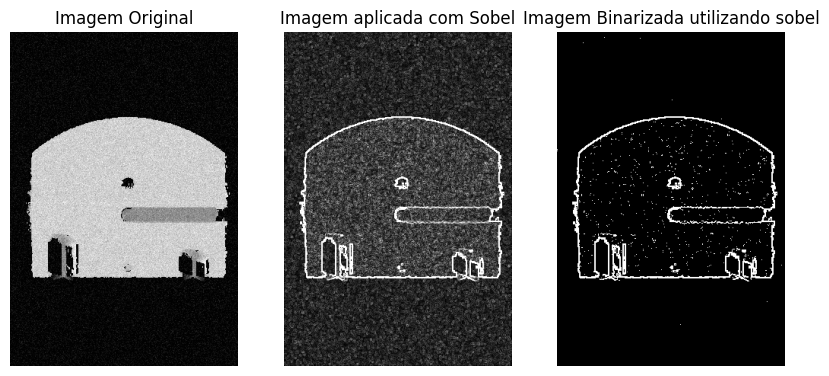

In [5]:
img1 = cv2.imread("ufo2noi2.png", cv2.IMREAD_GRAYSCALE)

# Máscara utilizando o operador de sobel (horizontal e vertical)
gradienteSobelH = np.array([[-1,-2,-1], [0,0,0], [1,2,1]])
gradienteSobelV = np.array([[-1, 0, 1], [-2,0,2], [-1,0,1]])

# Filtro utilizando sobel
filtroHorizontal = cv2.filter2D(img1, cv2.CV_64F, gradienteSobelH)
filtroVertical = cv2.filter2D(img1, cv2.CV_64F, gradienteSobelV)

# Imagens tem valores negativos, por isso a conversão, senão não dá pra ver
raiz = np.sqrt(filtroHorizontal**2 + filtroVertical**2)
imgSobel = cv2.convertScaleAbs(raiz)

# Threshold da imagem, > 150 vira branco (255), < 150 vira preto (0)
_, imgSobelBinarizada = cv2.threshold(imgSobel, thresh=150, maxval=255, type=cv2.THRESH_BINARY)

# Para exibição
plt.figure(figsize=(10, 5))

# Imagem Original
plt.subplot(1,3,1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem Original")
plt.axis('off')

# Imagem aplicando Sobel
plt.subplot(1,3,2)
plt.imshow(imgSobel, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem aplicada com Sobel")
plt.axis('off')

# Imagem aplicando binarização no Sobel
plt.subplot(1,3,3)
plt.imshow(imgSobelBinarizada, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem Binarizada utilizando sobel")
plt.axis('off')